<a href="https://colab.research.google.com/github/yogitaalone04-web/machine-learning-practicals/blob/main/PostLab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CS24D017: Yogita Alone

AIM:To implement a complete regression problem by
performing data preprocessing, model building, evaluation, and
result interpretation.

In [4]:
import pandas as pd
import numpy as np

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd
path="/content/drive/MyDrive/ML_Dataset/Car_Price_Prediction.csv"
df=pd.read_csv(path)
df.head(5)

,Make,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,Price
0,Honda,Model B,2015,3.9,74176,Petrol,Manual,30246.207931
1,Ford,Model C,2014,1.7,94799,Electric,Automatic,22785.747684
2,BMW,Model B,2006,4.1,98385,Electric,Manual,25760.290347
3,Honda,Model B,2015,2.6,88919,Electric,Automatic,25638.003491
4,Honda,Model C,2004,3.4,138482,Petrol,Automatic,21021.386657


In [7]:
df = df.dropna()

In [8]:
df = pd.get_dummies(df, drop_first=True)

In [10]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

MODEL 1 - Linear Regression

In [13]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

 MODEL 2 - Decision Tree

In [14]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

MODEL 3 - Random Forest

In [15]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

# Evaluation

In [17]:
from sklearn.metrics import mean_squared_error, r2_score

def evaluate(name, y_test, pred):
    print(f"--- {name} ---")
    print("MSE:", mean_squared_error(y_test, pred))
    print("R2 Score:", r2_score(y_test, pred))
    print()

evaluate("Linear Regression", y_test, pred_lr)
evaluate("Decision Tree", y_test, pred_dt)
evaluate("Random Forest", y_test, pred_rf)

--- Linear Regression ---
MSE: 5005471.209265246
R2 Score: 0.8170961815662064

--- Decision Tree ---
MSE: 11121439.616945673
R2 Score: 0.5936139301620669

--- Random Forest ---
MSE: 5622792.308869231
R2 Score: 0.7945387875473742



# Visualization

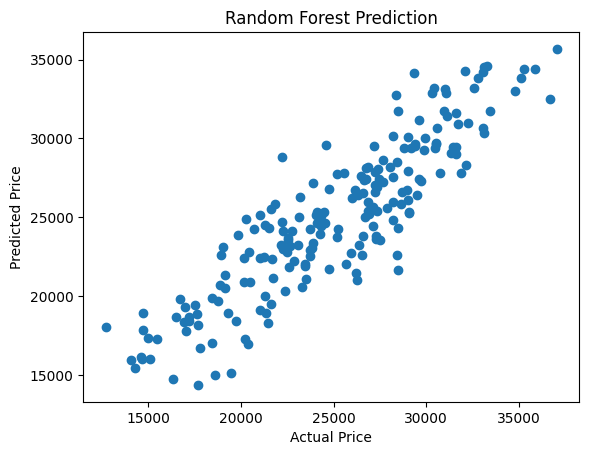

In [18]:
import matplotlib.pyplot as plt

plt.scatter(y_test, pred_rf)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest Prediction")
plt.show()